In [1]:
from openpiv import tools, pyprocess, validation, filters, scaling

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import imageio
import importlib_resources
import pathlib

In [2]:
path = importlib_resources.files('openpiv')

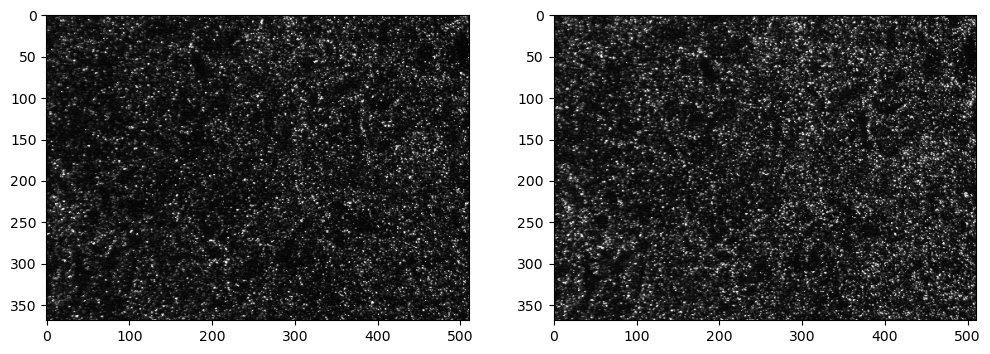

In [3]:
frame_a  = tools.imread( path / 'data/test1/exp1_001_a.bmp' )
frame_b  = tools.imread( path / 'data/test1/exp1_001_b.bmp' )

fig,ax = plt.subplots(1,2,figsize=(12,10))
ax[0].imshow(frame_a,cmap=plt.cm.gray);
ax[1].imshow(frame_b,cmap=plt.cm.gray);

In [4]:
winsize = 32 # pixels, interrogation window size in frame A
searchsize = 38  # pixels, search area size in frame B
overlap = 17 # pixels, 50% overlap
dt = 0.02 # sec, time interval between the two frames

u0, v0, sig2noise = pyprocess.extended_search_area_piv(
    frame_a.astype(np.int32),
    frame_b.astype(np.int32),
    window_size=winsize,
    overlap=overlap,
    dt=dt,
    search_area_size=searchsize,
    sig2noise_method='peak2peak',
)

In [5]:
x, y = pyprocess.get_coordinates(
    image_size=frame_a.shape,
    search_area_size=searchsize,
    overlap=overlap,
)

In [12]:
invalid_mask = validation.sig2noise_val(u0, v0, sig2noise, w=None, threshold=1.05)

In [13]:
u2, v2 = filters.replace_outliers(u0, v0, invalid_mask, method='localmean', max_iter=3,kernel_size=3) 

In [14]:
# convert x,y to mm
# convert u,v to mm/sec

x, y, u3, v3 = scaling.uniform(
    x, y, u2, v2,
    scaling_factor = 96.52,  # 96.52 pixels/millimeter
)

# 0,0 shall be bottom left, positive rotation rate is counterclockwise
x, y, u3, v3 = tools.transform_coordinates(x, y, u3, v3)

In [15]:
tools.save('exp1_001.txt' , x, y, u3, v3, invalid_mask)

AttributeError: 'str' object has no attribute 'flatten'

FileNotFoundError: exp1_001.txt not found.

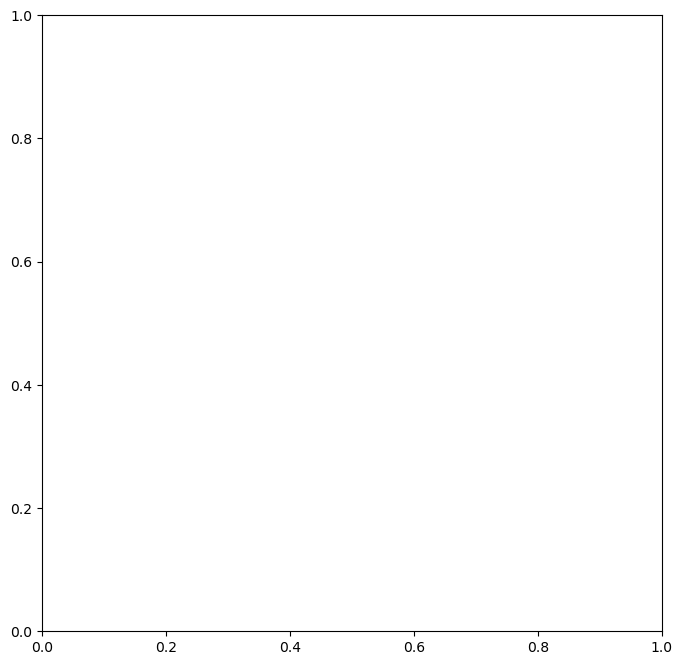

In [16]:
fig, ax = plt.subplots(figsize=(8,8))
tools.display_vector_field(
    pathlib.Path('exp1_001.txt'),
    ax=ax, scaling_factor=96.52,
    scale=50, # scale defines here the arrow length
    width=0.0035, # width is the thickness of the arrow
    on_img=True, # overlay on the image
    image_name= str(path / 'data'/'test1'/'exp1_001_a.bmp'),
);